In [1]:
#load libraries
from pyspark.sql import SparkSession
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import lit
import glob
from pyspark.sql.functions import to_date
from pyspark.sql.functions import count
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
from pyspark.sql.functions import col

In [2]:
""""#initializing spark 
#trying difernt connectors and jars to deal with error messages
spark = SparkSession.builder \
    .appName("Stock Tweets Analysis") \
    .master("local[*]") \
    .config("spark.jars", 
            "/home/hduser/Downloads/bson-4.9.0.jar,"
            "/home/hduser/Downloads/mongodb-driver-sync-4.9.0.jar,"
            "/home/hduser/Downloads/mongo-spark-connector_2.12-10.1.1.jar") \
    .config("spark.mongodb.connection.uri", "mongodb://127.0.0.1/") \
    .getOrCreate()

#trying to load from MongoDB
df = spark.read.format("mongodb") \
    .option("database", "CA2") \
    .option("collection", "tweets") \
    .load()

#read data
df.show(5)"""

'"#initializing spark \n#trying difernt connectors and jars to deal with error messages\nspark = SparkSession.builder     .appName("Stock Tweets Analysis")     .master("local[*]")     .config("spark.jars", \n            "/home/hduser/Downloads/bson-4.9.0.jar,"\n            "/home/hduser/Downloads/mongodb-driver-sync-4.9.0.jar,"\n            "/home/hduser/Downloads/mongo-spark-connector_2.12-10.1.1.jar")     .config("spark.mongodb.connection.uri", "mongodb://127.0.0.1/")     .getOrCreate()\n\n#trying to load from MongoDB\ndf = spark.read.format("mongodb")     .option("database", "CA2")     .option("collection", "tweets")     .load()\n\n#read data\ndf.show(5)'

MongoDB and Spark failed to connect, loading data from hdfs instead

In [3]:
"""#initializing spark
spark = SparkSession.builder \
    .appName("Load Tweets from HDFS") \
    .getOrCreate()

# reading in data from hdfs
tweets = spark.read.csv("hdfs:///user/hduser/stocktweet/stocktweet.csv", header=True, inferSchema=True)

tweets.show(5)"""

'#initializing spark\nspark = SparkSession.builder     .appName("Load Tweets from HDFS")     .getOrCreate()\n\n# reading in data from hdfs\ntweets = spark.read.csv("hdfs:///user/hduser/stocktweet/stocktweet.csv", header=True, inferSchema=True)\n\ntweets.show(5)'

In [4]:
#reading in data for stockprice 
stock_df = spark.read.option("header", "true").option("inferSchema", "true") \
    .csv("hdfs://localhost:9000/user/hduser/stockprice")

In [5]:
#check has been read in correctly
stock_df.show(5)
stock_df.printSchema()

+----------+------------------+-----------------+-----------------+-----------------+------------------+--------+
|      date|              open|             high|              low|            close|         adj_close|  volume|
+----------+------------------+-----------------+-----------------+-----------------+------------------+--------+
|2019-12-31| 36.80265808105469|  37.191650390625|36.72675323486328|37.17267608642578| 31.37105178833008|15175703|
|2020-01-02|37.286529541015625|37.33396530151367|36.88804626464844|37.13472366333008|31.339025497436523|16514072|
|2020-01-03| 36.73624420166016| 37.2296028137207|36.68880462646485|36.93548583984375|31.170879364013672|14922848|
|2020-01-06| 36.83111953735352|37.00189971923828|36.71726989746094|36.88804626464844| 31.13084602355957|15771951|
|2020-01-07| 37.11574935913086|37.12523651123047|36.69829177856445|36.76470565795898|31.026758193969727|20108107|
+----------+------------------+-----------------+-----------------+-----------------+---

In [6]:
#loading tweets data
tweets_df = spark.read.option("header", "true").option("inferSchema", "true") \
    .csv("hdfs://localhost:9000/user/hduser/tweets")

In [7]:
#checking read in correctly
tweets_df.show(5)
tweets_df.printSchema()

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



In [8]:
#checking distinct dates from files, and company names
stock_df.select("Date").distinct().show(5)
tweets_df.select("ticker", "date").distinct().show(5)

+----------+
|      Date|
+----------+
|2020-08-24|
|2020-01-21|
|2020-07-24|
|2020-08-05|
|2020-04-30|
+----------+
only showing top 5 rows

+------+----------+
|ticker|      date|
+------+----------+
|  TSLA|28/01/2020|
|  AMZN|07/02/2020|
|   MCD|11/02/2020|
|   CCL|31/03/2020|
|  NFLX|17/04/2020|
+------+----------+
only showing top 5 rows



In [9]:
#getting error in cell below due to "GOOG" file, going to look at GOOG and GOOGL to see if they should be merged 
#possible name different due to ticker chnage

goog_df = spark.read.option("header", "true").option("inferSchema", "true").csv("file:///home/hduser/Downloads/stockprice/GOOG.csv")

googl_df = spark.read.option("header", "true").option("inferSchema", "true").csv("file:///home/hduser/Downloads/stockprice/GOOGL.csv")

print("GOOG:")
goog_df.show(5)

print("GOOGL:")
googl_df.show(5)

GOOG:
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+--------+
|      date|             open|             high|              low|            close|        adj_close|  volume|
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+--------+
|2019-12-31|66.50550079345703| 66.9000015258789| 66.4542465209961|66.85099792480469|66.85099792480469|19236000|
|2020-01-02|67.07749938964844|68.40699768066406|67.07749938964844|68.36849975585938|68.36849975585938|28132000|
|2020-01-03|67.39299774169922|           68.625| 67.2771987915039|68.03299713134766|68.03299713134766|23728000|
|2020-01-06|             67.5|69.82499694824219|             67.5|69.71050262451172|69.71050262451172|34646000|
|2020-01-07|69.89700317382812|70.14949798583984|69.51899719238281|69.66699981689453|69.66699981689453|30054000|
+----------+-----------------+-----------------+-----------------+-----------------+--------------

Quick google search shows that these are linked with the same company but with two different types of stockholders: "Alphabet, Google's parent company, has two listed share classes that use slightly different ticker symbols. GOOGL shares are its Class A shares, also known as common stock, which have the typical one-share, one-vote structure. GOOG shares are Class C shares that confer no voting rights"

https://www.investopedia.com/ask/answers/052615/whats-difference-between-googles-goog-and-googl-stock-tickers.asp#:~:text=Alphabet%2C%20Google's%20parent%20company%2C%20has,that%20confer%20no%20voting%20rights.

In [10]:
#need to add company names to the stock price files (from original file names) 
#so the data for each compay can be distinguished from eachother and used to combine with related tweets

# Initialize Spark
spark = SparkSession.builder.appName("CombineStockFiles").getOrCreate()

folder_path = "/home/hduser/Downloads/stockprice/"

# getting all .csv file paths
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# List to hold DataFrames
df_list = []

for file_path in csv_files:
    # extracting the filename to use in column
    ticker = os.path.basename(file_path).replace(".csv", "")

    # reading the csv file
    df = spark.read.option("header", "true").option("inferSchema", "true") \
        .csv(f"file://{file_path}")
    #adding the ticker column
    df = df.withColumn("ticker", lit(ticker))
    df_list.append(df)

# combing all DataFrames
combined_df = df_list[0]
for df in df_list[1:]:
    combined_df = combined_df.unionByName(df)

# saving as one csv file
combined_df.write.mode("overwrite").option("header", "true") \
    .csv("file:///home/hduser/Downloads/all_stock_data")

print("Combined stock data saved successfully.")

25/05/03 08:41:13 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Combined stock data saved successfully.


Files uploaded to hdfs: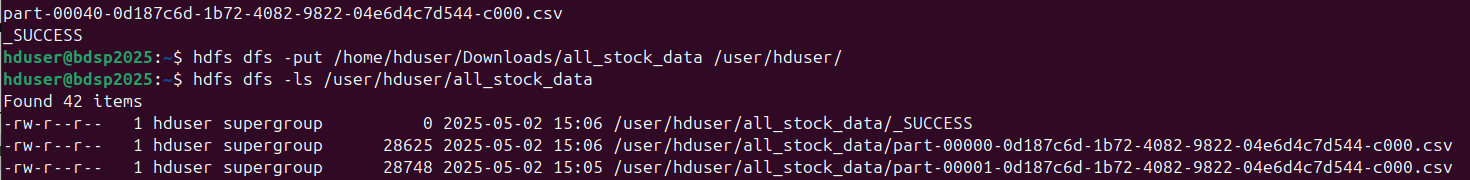

Table created in hive: 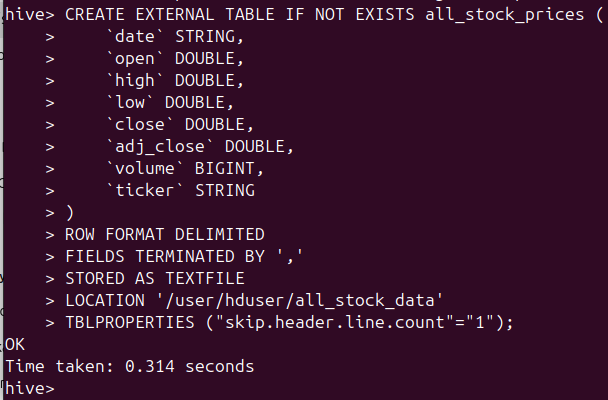, 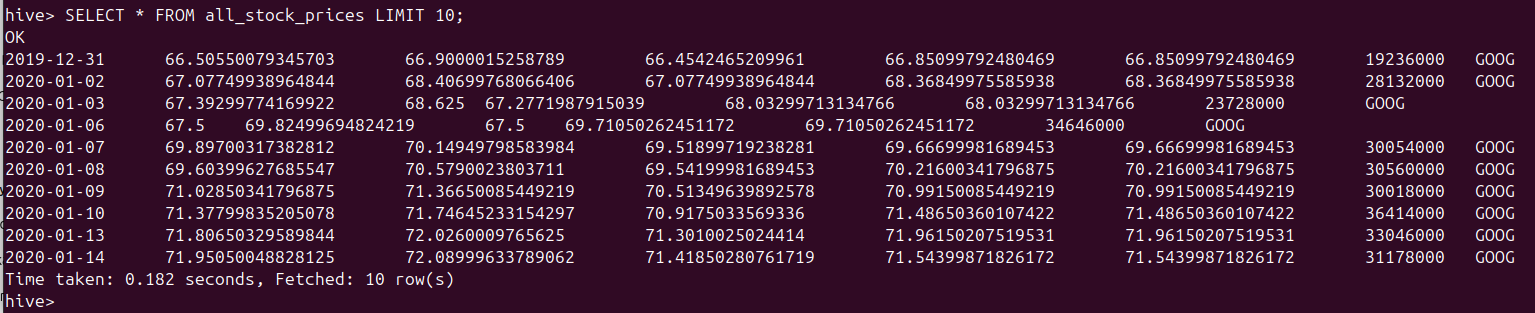

In [11]:
#Initializing spark
#spark = SparkSession.builder \
#    .appName("StockAnalysis") \
#    .enableHiveSupport() \
#    .getOrCreate()

In [12]:
#reading in the combined stock price data from HIVE
#stock_df = spark.sql("SELECT * FROM all_stock_prices")... issues connecting HIVE to spark, loading from hdfs instead

In [13]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("Stock Data Analysis") \
    .getOrCreate()

# reading combined stock data from HDFS
stock_df = spark.read.option("header", "true").option("inferSchema", "true") \
    .csv("hdfs://localhost:9000/user/hduser/all_stock_data")

25/05/03 08:41:26 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [14]:
#check loaded correctly
stock_df.show(5)
stock_df.printSchema()

+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|      date|              open|              high|               low|             close|         adj_close|   volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|2019-12-31|              27.0|28.086000442504883| 26.80533218383789|  27.8886661529541|  27.8886661529541|154285500|  TSLA|
|2020-01-02|28.299999237060547| 28.71333312988281| 28.11400032043457| 28.68400001525879| 28.68400001525879|142981500|  TSLA|
|2020-01-03| 29.36666679382324| 30.26666641235352| 29.12800025939941| 29.53400039672852| 29.53400039672852|266677500|  TSLA|
|2020-01-06| 29.36466789245605| 30.10400009155273|29.333332061767575|  30.1026668548584|  30.1026668548584|151995000|  TSLA|
|2020-01-07| 30.76000022888184|31.441999435424805|30.224000930786133|31.270666122436523|31.270666122436523|268231500|  TSLA|


### Processing data

In [15]:
# fixing the date format to match
tweets_df = tweets_df.withColumn("date", to_date("date", "dd/MM/yyyy"))

In [16]:
#getting tweets per day for each ticker
tweet_counts = tweets_df.groupBy("ticker", "date").agg(count("*").alias("tweet_count"))
tweet_counts.show()

+------+----------+-----------+
|ticker|      date|tweet_count|
+------+----------+-----------+
|  AAPL|2020-01-03|          6|
|  AAPL|2020-01-09|          4|
|  AAPL|2020-01-17|          3|
|   CCL|2020-03-05|          1|
|   DIS|2020-03-06|         10|
|   BAC|2020-03-10|          1|
|  BABA|2020-03-18|          1|
|   CCL|2020-03-27|          4|
|   CCL|2020-05-01|          3|
|  AMZN|2020-09-23|          1|
|  AAPL|2020-10-29|         25|
|   CCL|2020-11-25|          1|
|  AAPL|2020-12-31|          3|
|    BA|2020-08-21|          1|
|    BA|2020-01-07|          2|
|    HD|2020-03-26|          1|
|    BA|2020-03-30|          2|
|  AAPL|2020-04-06|          1|
|   DIS|2020-07-10|          1|
|     V|2020-08-04|          1|
+------+----------+-----------+
only showing top 20 rows



In [17]:
#group by ticker and count how many tweets for each company
top_tickers = tweets_df.groupBy("ticker").agg(count("*").alias("tweet_count"))
top_tickers = top_tickers.orderBy("tweet_count", ascending=False)
top_tickers.show(10)

+------+-----------+
|ticker|tweet_count|
+------+-----------+
|  TSLA|       4341|
|  AAPL|       1721|
|  null|       1119|
|    BA|        919|
|   DIS|        432|
|  AMZN|        407|
|  MSFT|        271|
|   CCL|        264|
|  BABA|        239|
|    FB|        204|
+------+-----------+
only showing top 10 rows



In [18]:
#get the top ten tickers for number of tweets
top_10_list = [row["ticker"] for row in top_tickers.limit(10).collect()]
print(top_10_list)

['TSLA', 'AAPL', None, 'BA', 'DIS', 'AMZN', 'MSFT', 'CCL', 'BABA', 'FB']


In [19]:
#trying to see if null tweets might contain info on some of the large companies before merge with stock data
keyword_to_ticker = {
    "tesla": "TSLA",
    "apple": "AAPL",
    "amazon": "AMZN",
    "boeing": "BA",
    "disney": "DIS",
    "microsoft": "MSFT",
    "carnival": "CCL",
    "alibaba": "BABA",
    "facebook": "FB",
    "meta": "FB",  # backup keyword
}
#filter so looking only at null tweet rows
null_tweets = tweets_df.filter(tweets_df["ticker"].isNull())

In [20]:
#UDF to scan tweets and apply ticker

def assign_ticker(tweet):
    if tweet is None:
        return None
    tweet_lower = tweet.lower()
    for keyword, ticker in keyword_to_ticker.items():
        if keyword in tweet_lower:
            return ticker
    return None

assign_ticker_udf = udf(assign_ticker, StringType())

# Apply to the null rows
null_tweets_fixed = null_tweets.withColumn("ticker", assign_ticker_udf(null_tweets["tweet"]))

In [21]:
#merge (hopefully) fixed nulls back in
non_null_tweets = tweets_df.filter(tweets_df["ticker"].isNotNull())
tweets_df_cleaned = non_null_tweets.unionByName(null_tweets_fixed)

In [22]:
#look at top 10 again and see if it has changed
top_tickers = tweets_df_cleaned.groupBy("ticker") \
    .agg(count("*").alias("tweet_count")) \
    .orderBy("tweet_count", ascending=False)

top_tickers.show(10)

+------+-----------+
|ticker|tweet_count|
+------+-----------+
|  TSLA|       4341|
|  AAPL|       1721|
|  null|       1119|
|    BA|        919|
|   DIS|        432|
|  AMZN|        407|
|  MSFT|        271|
|   CCL|        264|
|  BABA|        239|
|    FB|        204|
+------+-----------+
only showing top 10 rows



Still same number of null items, but at least I tried to extract them!

### Combine tweets and stock data to make new dataframes
One large data set with just the top 9 copanies for tweet volume
then one dataframe fro each of these companies

In [23]:
#first get data to correct format in stock_df
stock_df = stock_df.withColumn("date", to_date("date", "yyyy-MM-dd"))

In [24]:
#focusing on the tickers with the most tweets, that are not null
top_9_list = [ticker for ticker in top_10_list if ticker is not None]
print(top_9_list)

['TSLA', 'AAPL', 'BA', 'DIS', 'AMZN', 'MSFT', 'CCL', 'BABA', 'FB']


In [25]:
#filtering both datasets to only include these tickers
tweets_top9 = tweets_df.filter(tweets_df.ticker.isin(top_9_list))
stock_top9 = stock_df.filter(stock_df.ticker.isin(top_9_list))

In [26]:
#join datasets on these tickers
joined_df = stock_top9.join(tweets_top9, on=["date", "ticker"], how="left") #left join to keep all stock data
joined_df.show(5)

+----------+------+------------------+------------------+-----------------+-----------------+-----------------+---------+------+--------------------+
|      date|ticker|              open|              high|              low|            close|        adj_close|   volume|    id|               tweet|
+----------+------+------------------+------------------+-----------------+-----------------+-----------------+---------+------+--------------------+
|2019-12-31|  TSLA|              27.0|28.086000442504883|26.80533218383789| 27.8886661529541| 27.8886661529541|154285500|  null|                null|
|2020-01-02|  TSLA|28.299999237060547| 28.71333312988281|28.11400032043457|28.68400001525879|28.68400001525879|142981500|108002|$TSLA Hate to say...|
|2020-01-03|  TSLA| 29.36666679382324| 30.26666641235352|29.12800025939941|29.53400039672852|29.53400039672852|266677500|100025|$TSLA Ignore the ...|
|2020-01-03|  TSLA| 29.36666679382324| 30.26666641235352|29.12800025939941|29.53400039672852|29.5340

In [27]:
#saving file
# Save to HDFS
joined_df.write.mode("overwrite").option("header", True) \
    .csv("hdfs://localhost:9000/user/hduser/merged_top9")

# Save to local VM directory
joined_df.write.mode("overwrite").option("header", True) \
    .csv("file:///home/hduser/merged_top9_local")

In [28]:
# getting separate files for each ticker and saving files
tickers = ['TSLA', 'AAPL', 'BA', 'DIS', 'AMZN', 'MSFT', 'CCL', 'BABA', 'FB']

for ticker in tickers:
    filtered_df = joined_df.filter(joined_df["ticker"] == ticker)
    
    # Save to HDFS
    filtered_df.write.mode("overwrite").option("header", True) \
        .csv(f"hdfs://localhost:9000/user/hduser/merged_{ticker.lower()}")
    
    # Save to local file system
    filtered_df.write.mode("overwrite").option("header", True) \
        .csv(f"file:///home/hduser/merged_{ticker.lower()}_local")

Success!
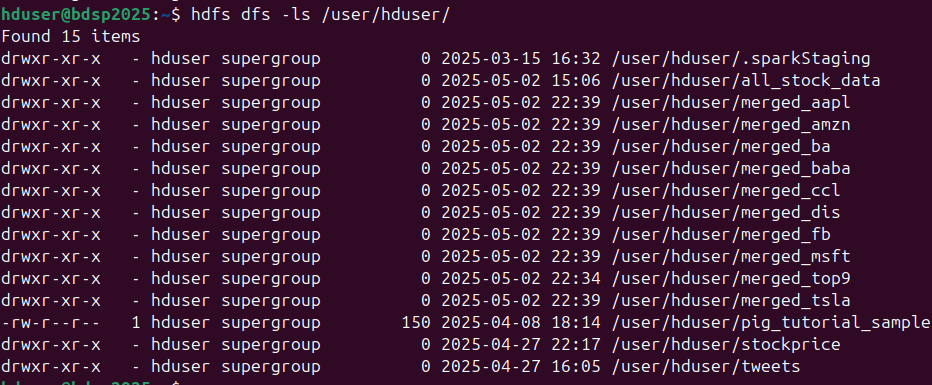
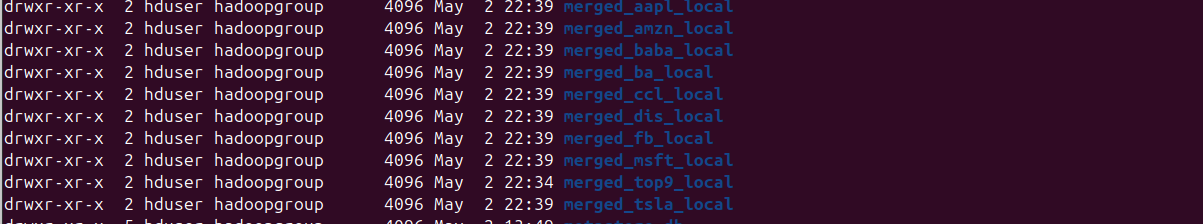

### Saving data to HIVE and MongoDB

In [31]:
#load the joined dataset from hdfs
joined_df = spark.read.option("header", "true").csv("hdfs://localhost:9000/user/hduser/merged_top9")

In [32]:
# Save to Hive (ensure Hive metastore is running)
joined_df.write.mode("overwrite").saveAsTable("merged_stock_tweets")

In [40]:
#Saving to MongoDB
"""joined_df.write \
    .format("mongo") \
    .option("uri", "mongodb://127.0.0.1/BDProject.merged") \
    .mode("overwrite") \
    .save()"""

'joined_df.write     .format("mongo")     .option("uri", "mongodb://127.0.0.1/BDProject.merged")     .mode("overwrite")     .save()'

In [41]:
#manually saving to mongodb using terminal instead as failed to connect with spark
#need to amend characters in tweets to dead with error from mongo db
joined_df.write.mode("overwrite") \
    .option("header", True) \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv("file:///home/hduser/merged_top9_local")

Data added to MongoDB sucessfully 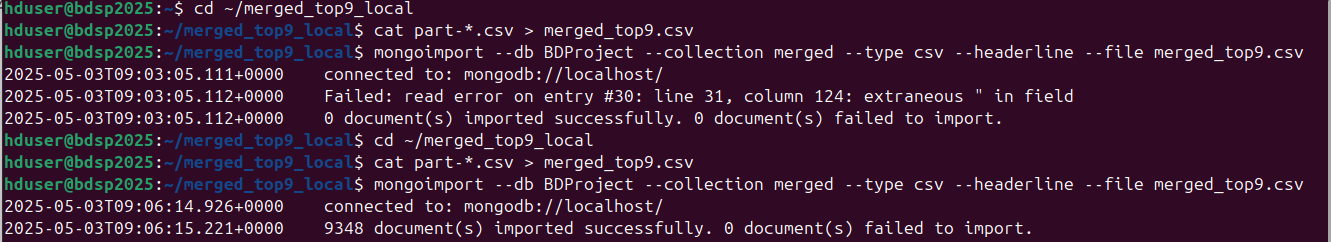

In [1]:
print("Processing complete. Data saved to HDFS, local filesystem, and manually inserted into MongoDB.")


Processing complete. Data saved to HDFS, local filesystem, and manually inserted into MongoDB.
